# f_N saturation check -- rolling-window estimator (method 1)

Combines two runs, both under the current rolling-window definition
(method 1, self-scaling patience burn-in, W=5L, M=10):

- `frozen_fraction_test_20260913T062809Z` (test.yaml, N=200-1600, 4 points)
- `frozen_fraction_production_intermediate_20260913T064716Z`
  (production_intermediate.yaml, N=100-10,000, 20 points)

Exploratory view tied to these two specific runs -- not a final,
citable analysis (no fitting here; see `notebooks/analysis/` once a
fit against the rolling-window data is done). Presented as-is, no
interpretation.

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

RUN_DIRS = [
    Path('../../data/raw/frozen_fraction_test_20260913T062809Z'),
    Path('../../data/raw/frozen_fraction_production_intermediate_20260913T064716Z'),
]

summary = []
for run_dir in RUN_DIRS:
    with open(run_dir / 'summary.json') as f:
        summary.extend(json.load(f))
summary = sorted(summary, key=lambda row: row['L'])

assert len(set(row['L'] for row in summary)) == len(summary), 'duplicate N across the two runs'

N = np.array([row['L'] for row in summary], dtype=float)
f = np.array([row['frozen_fraction_mean'] for row in summary])
se = np.array([row['frozen_fraction_se'] for row in summary])
n_samples = np.array([row['n_samples'] for row in summary])

print(f'{len(N)} combined points, N={int(N.min())}..{int(N.max())}')
for n_i, f_i, se_i, ns_i in zip(N, f, se, n_samples):
    print(f"N={int(n_i):6d}  f_N={f_i:.4f} +- {se_i:.4f}  (n={ns_i})")

24 combined points, N=100..10000
N=   100  f_N=0.3538 +- 0.0035  (n=1340)
N=   200  f_N=0.3861 +- 0.0209  (n=20)
N=   400  f_N=0.3808 +- 0.0173  (n=20)
N=   621  f_N=0.3602 +- 0.0036  (n=220)
N=   800  f_N=0.3540 +- 0.0072  (n=20)
N=  1142  f_N=0.3656 +- 0.0036  (n=120)
N=  1600  f_N=0.3599 +- 0.0060  (n=20)
N=  1663  f_N=0.3624 +- 0.0035  (n=80)
N=  2184  f_N=0.3628 +- 0.0035  (n=60)
N=  2705  f_N=0.3646 +- 0.0034  (n=60)
N=  3226  f_N=0.3583 +- 0.0028  (n=60)
N=  3747  f_N=0.3671 +- 0.0034  (n=20)
N=  4268  f_N=0.3638 +- 0.0028  (n=60)
N=  4789  f_N=0.3623 +- 0.0036  (n=20)
N=  5311  f_N=0.3656 +- 0.0034  (n=20)
N=  5832  f_N=0.3643 +- 0.0025  (n=20)
N=  6353  f_N=0.3605 +- 0.0029  (n=40)
N=  6874  f_N=0.3620 +- 0.0031  (n=20)
N=  7395  f_N=0.3682 +- 0.0035  (n=20)
N=  7916  f_N=0.3623 +- 0.0019  (n=20)
N=  8437  f_N=0.3631 +- 0.0028  (n=20)
N=  8958  f_N=0.3676 +- 0.0026  (n=20)
N=  9479  f_N=0.3619 +- 0.0024  (n=20)
N= 10000  f_N=0.3652 +- 0.0025  (n=20)


## Pure f_N vs N (before any scaling transform)

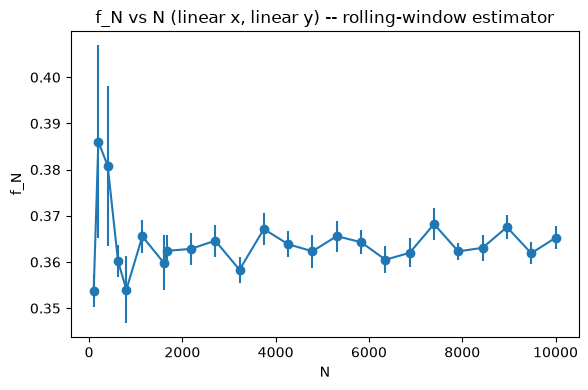

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(N, f, yerr=se, marker='o', linestyle='-')
ax.set_xlabel('N')
ax.set_ylabel('f_N')
ax.set_title('f_N vs N (linear x, linear y) -- rolling-window estimator')
fig.tight_layout()
plt.show()

## Saturation views: log x, 1/N, ln(N)

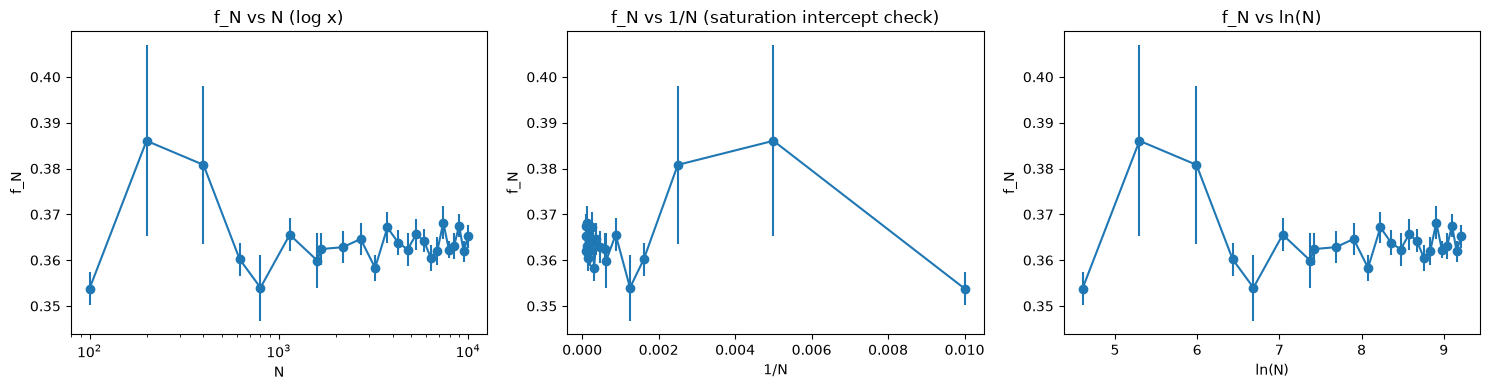

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.errorbar(N, f, yerr=se, marker='o', linestyle='-')
ax.set_xscale('log')
ax.set_xlabel('N')
ax.set_ylabel('f_N')
ax.set_title('f_N vs N (log x)')

ax = axes[1]
ax.errorbar(1.0 / N, f, yerr=se, marker='o', linestyle='-')
ax.set_xlabel('1/N')
ax.set_ylabel('f_N')
ax.set_title('f_N vs 1/N (saturation intercept check)')

ax = axes[2]
ax.errorbar(np.log(N), f, yerr=se, marker='o', linestyle='-')
ax.set_xlabel('ln(N)')
ax.set_ylabel('f_N')
ax.set_title('f_N vs ln(N)')

fig.tight_layout()
plt.show()

## Weighted mean as a naive saturation-constant estimate

Not a fit -- just the inverse-variance-weighted mean across all 24
points, shown as a horizontal reference line against the data. A real
model comparison (constant vs power-law vs log decay) belongs in
`notebooks/analysis/`, not here.

Weighted mean f_N across all 24 points: 0.36303 +- 0.00065


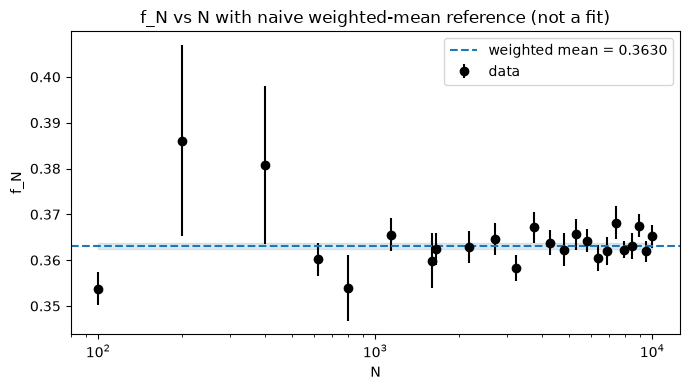

In [4]:
weights = 1.0 / se**2
f_weighted_mean = np.sum(f * weights) / np.sum(weights)
f_weighted_mean_err = np.sqrt(1.0 / np.sum(weights))
print(f'Weighted mean f_N across all {len(N)} points: {f_weighted_mean:.5f} +- {f_weighted_mean_err:.5f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(N, f, yerr=se, fmt='o', color='black', label='data')
ax.axhline(f_weighted_mean, color='C0', linestyle='--',
           label=f'weighted mean = {f_weighted_mean:.4f}')
ax.fill_between([N.min(), N.max()],
                 f_weighted_mean - f_weighted_mean_err,
                 f_weighted_mean + f_weighted_mean_err,
                 color='C0', alpha=0.15)
ax.set_xscale('log')
ax.set_xlabel('N')
ax.set_ylabel('f_N')
ax.set_title('f_N vs N with naive weighted-mean reference (not a fit)')
ax.legend()
fig.tight_layout()
plt.show()